# Laboratory #4: Adversarial Learning and OOD Detection

In this laboratory session we will develop a methodology for detecting OOD samples and measuring the quality of OOD detection. We will also experiment with incorporating adversarial examples during training to render models more robust to adversarial attacks.

---
## Exercise 1: OOD Detection and Performance Evaluation
In this first exercise you will build a simple OOD detection pipeline and implement some performance metrics to evaluate its performance.

### Exercise 1.1: Build a simple OOD detection pipeline

Implement an OOD detection pipeline (like in the Flipped Activity notebook) using an ID and an OOD dataset of your choice. Some options:

+ CIFAR-10 (ID), Subset of CIFAR-100 (OOD). You will need to wrap CIFAR-100 in some way to select a subset of classes that are *not* in CIFAR-10 (see `torch.utils.data.Subset`).
+ Labeled Faces in the Wild (ID), CIFAR-10 or FakeData (OOD). The LfW dataset is available in Scikit-learn (see `sklearn.datasets.fetch_lfw_people`).
+ Something else, but if using images keep the images reasonably small!

In this exercise your *OOD Detector* should produce a score representing how "out of distribution" a test sample is. We will implement some metrics in the next exercise, but for now use the techniques from the flipped activity notebook to judge how well OOD scoring is working (i.e. histograms).

**Note**: Make sure you make a validation split of your ID dataset for testing.

In [17]:
# --- 1. Setup ---
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import Subset, random_split
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [18]:
# --- 2. Model definition ---
# Must match EXACTLY the architecture used to produce the provided checkpoints
# (same as the professor's Flipped Activity notebook), otherwise load_state_dict fails.
class CNN(nn.Module):
    def __init__(self, dropout=False):
        super().__init__()
        self.dropout = dropout
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1)  # downsample
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)  # downsample

        self.flatten_dim = 256 * 8 * 8  # assuming input is 32x32
        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = torch.flatten(x, 1)
        if self.dropout:
            x = F.dropout(F.relu(self.fc1(x)))
            x = F.dropout(F.relu(self.fc2(x)))
        else:
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [19]:
# --- 3. ID dataset: CIFAR-10, with train/val/test split ---
# Same normalization used to train the provided checkpoints -- must match
# exactly, otherwise the model sees inputs in a different range than expected.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

batch_size = 128

id_train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
id_test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# The exercise explicitly asks for a validation split of the ID data.
val_size = int(0.1 * len(id_train_full))
train_size = len(id_train_full) - val_size
id_train, id_val = random_split(id_train_full, [train_size, val_size])

id_val_loader = torch.utils.data.DataLoader(id_val, batch_size=batch_size, shuffle=False)
id_test_loader = torch.utils.data.DataLoader(id_test, batch_size=batch_size, shuffle=False)

print(f"ID train: {len(id_train)}, ID val: {len(id_val)}, ID test: {len(id_test)}")

ID train: 45000, ID val: 5000, ID test: 10000


In [20]:
# --- 4. OOD dataset: a "far" subset of CIFAR-100 ---
# We pick CIFAR-100 fine classes with NO semantic overlap with any CIFAR-10
# class (CIFAR-10 = airplane, automobile, bird, cat, deer, dog, frog, horse,
# ship, truck -- i.e. only vehicles and animals). We deliberately avoid all
# CIFAR-100 animal/vehicle classes and pick from clearly unrelated categories
# (flowers, food containers, man-made outdoor structures).
cifar100_full = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=transform)

FAR_OOD_CLASSES = [
    "orchid", "poppy", "rose", "sunflower", "tulip",          # flowers
    "bottle", "bowl", "can", "cup", "plate",                   # food containers
    "bridge", "castle", "house", "road", "skyscraper",         # large man-made outdoor things
]
far_ood_indices = [cifar100_full.class_to_idx[c] for c in FAR_OOD_CLASSES]

ood_indices = [i for i, (_, label) in enumerate(cifar100_full) if label in far_ood_indices]
ood_dataset = Subset(cifar100_full, ood_indices)
ood_loader = torch.utils.data.DataLoader(ood_dataset, batch_size=batch_size, shuffle=False)

print(f"OOD samples (far subset of CIFAR-100): {len(ood_dataset)}")

OOD samples (far subset of CIFAR-100): 1500


In [21]:
import json

def train_cnn(dropout: bool, epochs: int = 50, lr: float = 1e-4):
    model = CNN(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in id_train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for x, y in id_val_loader:
                    x, y = x.to(device), y.to(device)
                    preds = model(x).argmax(dim=1)
                    correct += (preds == y).sum().item()
                    total += y.size(0)
            val_acc = correct / total
            train_loss = running_loss / len(id_train_loader)
            history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_acc": val_acc})
            print(f"Epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val acc: {val_acc:.4f}")

    return model, history


def get_model(dropout: bool, checkpoint_path: str, epochs: int = 50, lr: float = 1e-4):
    model = CNN(dropout=dropout)
    history_path = checkpoint_path.replace(".pth", "_history.json")

    if os.path.exists(checkpoint_path):
        print(f"Found existing checkpoint at {checkpoint_path}, loading it.")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model = model.to(device)

        if os.path.exists(history_path):
            # Re-print the training history saved alongside the checkpoint,
            # so you see the same epoch-by-epoch progression as a fresh run.
            with open(history_path) as f:
                history = json.load(f)
            for h in history:
                print(f"Epoch {h['epoch']}/{epochs} - train loss: {h['train_loss']:.4f} - val acc: {h['val_acc']:.4f}")
        else:
            # This checkpoint was trained before we started saving history --
            # at least recompute today's validation accuracy as a fallback.
            print("(No saved history for this checkpoint -- recomputing current val accuracy.)")
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for x, y in id_val_loader:
                    x, y = x.to(device), y.to(device)
                    preds = model(x).argmax(dim=1)
                    correct += (preds == y).sum().item()
                    total += y.size(0)
            print(f"Val acc: {correct/total:.4f}")
    else:
        print(f"No checkpoint found at {checkpoint_path}, training from scratch.")
        model, history = train_cnn(dropout=dropout, epochs=epochs, lr=lr)
        torch.save(model.state_dict(), checkpoint_path)
        with open(history_path, "w") as f:
            json.dump(history, f)

    return model


cnn_baseline = get_model(dropout=False, checkpoint_path="checkpoints/cnn_baseline.pth")
cnn_dropout = get_model(dropout=True, checkpoint_path="checkpoints/cnn_dropout.pth")

Found existing checkpoint at checkpoints/cnn_baseline.pth, loading it.
Epoch 10/50 - train loss: 0.8455 - val acc: 0.6234
Epoch 20/50 - train loss: 0.1260 - val acc: 0.6290
Epoch 30/50 - train loss: 0.0421 - val acc: 0.6306
Epoch 40/50 - train loss: 0.0305 - val acc: 0.6356
Epoch 50/50 - train loss: 0.0164 - val acc: 0.6372
Found existing checkpoint at checkpoints/cnn_dropout.pth, loading it.
Epoch 10/50 - train loss: 1.1723 - val acc: 0.5716
Epoch 20/50 - train loss: 0.7850 - val acc: 0.6328
Epoch 30/50 - train loss: 0.4793 - val acc: 0.6542
Epoch 40/50 - train loss: 0.3031 - val acc: 0.6580
Epoch 50/50 - train loss: 0.2176 - val acc: 0.6460


ID scores  -- mean: 0.9359, std: 0.1296
OOD scores -- mean: 0.9029, std: 0.1497


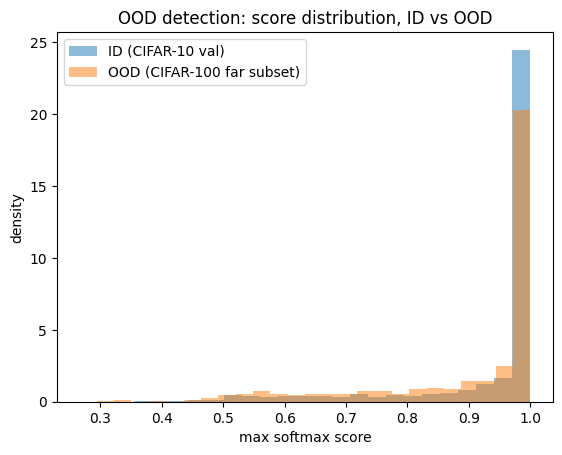

In [22]:
# --- 6. OOD scores: ID (CIFAR-10 val) vs OOD (CIFAR-100 far subset) ---

def max_logit(logit):
    return logit.max(dim=1)[0]

def max_softmax(logit, T=1.0):
    s = F.softmax(logit / T, dim=1)
    return s.max(dim=1)[0]

def compute_scores(data_loader, score_fun, model):
    scores = []
    model.eval()
    with torch.no_grad():
        for x, y in data_loader:
            output = model(x.to(device))
            scores.append(score_fun(output))
    return torch.cat(scores)

id_scores = compute_scores(id_val_loader, max_softmax, cnn_baseline)
ood_scores = compute_scores(ood_loader, max_softmax, cnn_baseline)

print(f"ID scores  -- mean: {id_scores.mean():.4f}, std: {id_scores.std():.4f}")
print(f"OOD scores -- mean: {ood_scores.mean():.4f}, std: {ood_scores.std():.4f}")

plt.hist(id_scores.cpu(), density=True, alpha=0.5, bins=25, label="ID (CIFAR-10 val)")
plt.hist(ood_scores.cpu(), density=True, alpha=0.5, bins=25, label="OOD (CIFAR-100 far subset)")
plt.xlabel("max softmax score")
plt.ylabel("density")
plt.legend()
plt.title("OOD detection: score distribution, ID vs OOD")
plt.show()

### Exercise 1.2: Measure your OOD detection performance

There are several metrics used to evaluate OOD detection performance, we will concentrate on two threshold-free approaches: the area under the Receiver Operator Characteristic (ROC) curve for ID classification, and the area under the Precision-Recall curve for *both* ID and OOD scoring. See [the ODIN paper](https://arxiv.org/pdf/1706.02690.pdf) section 4.3 for a description of OOD metrics.

Use the functions in `sklearn.metrics` to produce ROC and PR curves for your OOD detector. Some useful functions:

+ [`sklearn.metric.RocCurveDisplay.from_predictions`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
+ [`sklearn.metrics.PrecisionRecallDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PrecisionRecallDisplay.html)


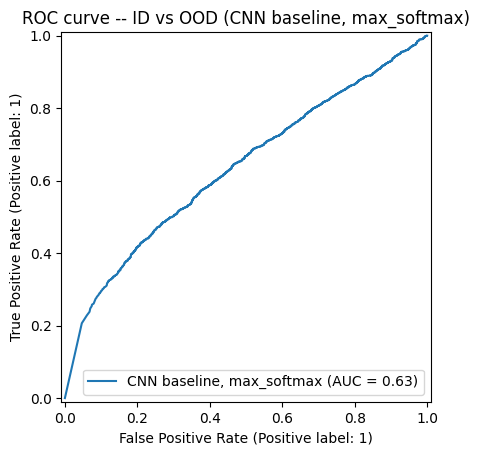

[CNN baseline, max_softmax] AUROC: 0.6348


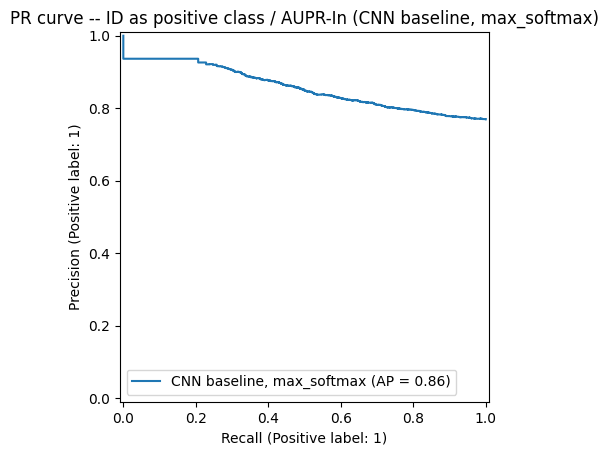

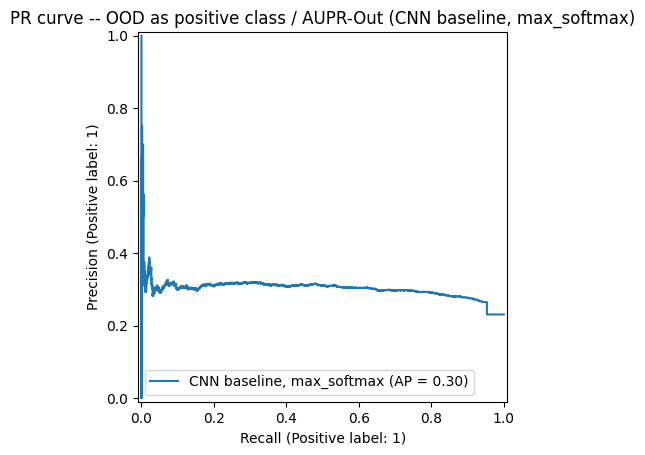

In [23]:
# --- Exercise 1.2: OOD detection metrics (ROC / PR curves) ---
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score

def evaluate_ood_detection(id_scores, ood_scores, label=""):
    """
    Given ID and OOD scores (higher score = more confidently in-distribution),
    plots the ROC curve and both PR curves (ID-positive and OOD-positive),
    and prints AUROC.
    """
    id_scores = id_scores.cpu().numpy()
    ood_scores = ood_scores.cpu().numpy()

    # Convention: label 1 = ID, label 0 = OOD. A higher score should mean
    # "more confidently ID" -- exactly what max_softmax/max_logit give us.
    y_true = np.concatenate([np.ones_like(id_scores), np.zeros_like(ood_scores)])
    y_score = np.concatenate([id_scores, ood_scores])

    # --- ROC curve: can we tell ID from OOD at all? ---
    RocCurveDisplay.from_predictions(y_true, y_score, name=label)
    plt.title(f"ROC curve -- ID vs OOD ({label})")
    plt.show()
    print(f"[{label}] AUROC: {roc_auc_score(y_true, y_score):.4f}")

    # --- PR curve, ID as positive class (AUPR-In) ---
    PrecisionRecallDisplay.from_predictions(y_true, y_score, name=label)
    plt.title(f"PR curve -- ID as positive class / AUPR-In ({label})")
    plt.show()

    # --- PR curve, OOD as positive class (AUPR-Out) ---
    # Swapping which class is "positive" also requires flipping the score:
    # a higher score must now mean "more confidently OOD" -- so we negate it.
    # (This is why AUPR-In and AUPR-Out are reported separately in the ODIN
    # paper: unlike ROC, PR curves are NOT symmetric under this swap.)
    y_true_ood = 1 - y_true
    y_score_ood = -y_score
    PrecisionRecallDisplay.from_predictions(y_true_ood, y_score_ood, name=label)
    plt.title(f"PR curve -- OOD as positive class / AUPR-Out ({label})")
    plt.show()


evaluate_ood_detection(id_scores, ood_scores, label="CNN baseline, max_softmax")

ID scores  (dropout model) -- mean: 0.8833, std: 0.1785
OOD scores (dropout model) -- mean: 0.7773, std: 0.2092


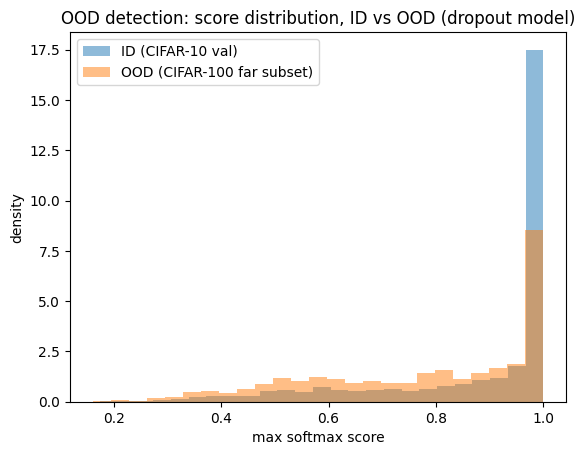

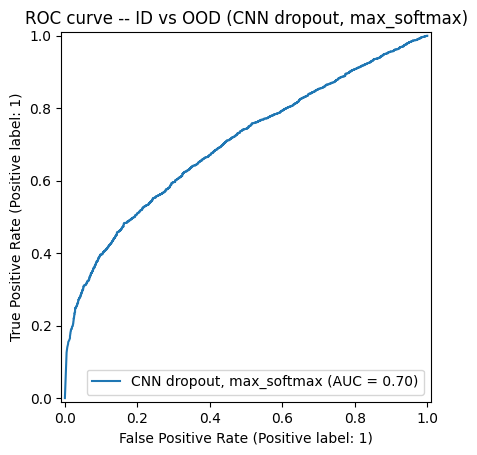

[CNN dropout, max_softmax] AUROC: 0.7017


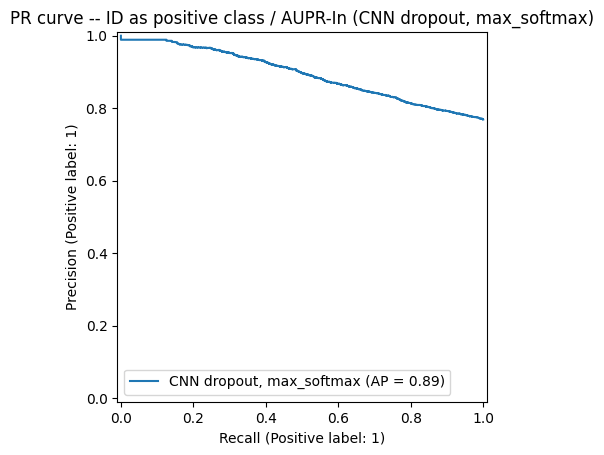

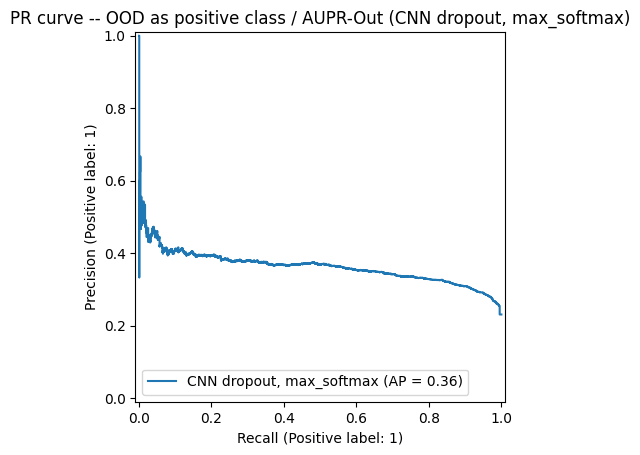

In [24]:
# --- Repeat scoring + evaluation on cnn_dropout ---

# Disable the stochastic dropout-at-inference behavior for this standard
# single-pass evaluation (it stays on by default even after model.eval(),
# since CNN.forward() calls F.dropout without training=self.training).
# We'll re-enable it later, on purpose, for the Monte Carlo Dropout part.
cnn_dropout.dropout = False

id_scores_dropout = compute_scores(id_val_loader, max_softmax, cnn_dropout)
ood_scores_dropout = compute_scores(ood_loader, max_softmax, cnn_dropout)

print(f"ID scores  (dropout model) -- mean: {id_scores_dropout.mean():.4f}, std: {id_scores_dropout.std():.4f}")
print(f"OOD scores (dropout model) -- mean: {ood_scores_dropout.mean():.4f}, std: {ood_scores_dropout.std():.4f}")

plt.hist(id_scores_dropout.cpu(), density=True, alpha=0.5, bins=25, label="ID (CIFAR-10 val)")
plt.hist(ood_scores_dropout.cpu(), density=True, alpha=0.5, bins=25, label="OOD (CIFAR-100 far subset)")
plt.xlabel("max softmax score")
plt.ylabel("density")
plt.legend()
plt.title("OOD detection: score distribution, ID vs OOD (dropout model)")
plt.show()

evaluate_ood_detection(id_scores_dropout, ood_scores_dropout, label="CNN dropout, max_softmax")

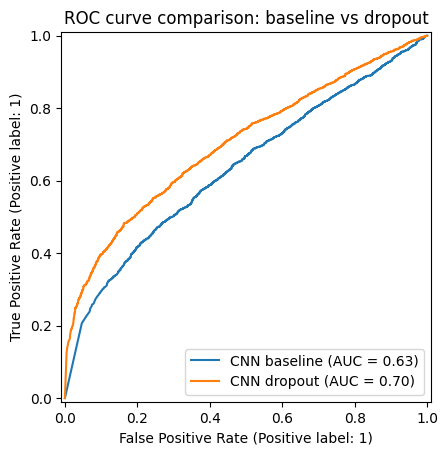

In [25]:
# --- Direct comparison: both models on the same ROC axes ---
fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(
    np.concatenate([np.ones(len(id_scores)), np.zeros(len(ood_scores))]),
    np.concatenate([id_scores.cpu().numpy(), ood_scores.cpu().numpy()]),
    name="CNN baseline", ax=ax,
)
RocCurveDisplay.from_predictions(
    np.concatenate([np.ones(len(id_scores_dropout)), np.zeros(len(ood_scores_dropout))]),
    np.concatenate([id_scores_dropout.cpu().numpy(), ood_scores_dropout.cpu().numpy()]),
    name="CNN dropout", ax=ax,
)
plt.title("ROC curve comparison: baseline vs dropout")
plt.show()

## Considerations

The dropout-regularized model outperforms the baseline on every OOD metric
(AUROC 0.70 vs 0.63, AUPR-In 0.89 vs 0.86, AUPR-Out 0.36 vs 0.30), not just
on validation accuracy -- suggesting that reducing overfitting also improves
the separability between ID and OOD confidence scores, not only in-distribution
performance. However, absolute AUROC remains moderate (0.70 at best): the score
histograms show that max-softmax saturates near 1.0 even for OOD inputs, a
known overconfidence issue with this scoring function. This motivates
exploring temperature scaling (Exercise 3.1 - ODIN) as a way to improve
separation without retraining the classifier.

---
## Exercise 2: Enhancing Robustness to Adversarial Attack

In this second exercise we will experiment with enhancing our base model to be (more) robust to adversarial attacks. 

### Exercise 2.1: Implement FGSM and generate adversarial examples

Recall that the Fast Gradient Sign Method (FGSM) perturbs samples in the direction of the gradient with respect to the input $\mathbf{x}$:
$$ \boldsymbol{\eta}(\mathbf{x}) = \varepsilon \mathrm{sign}(\nabla_{\mathbf{x}} \mathcal{L}(\boldsymbol{\theta}, \mathbf{x}, y)) ) $$
Implement FGSM and generate some *adversarial examples* using your trained ID model. Evaluate these samples qualitatively and quantitatively. Evaluate how dependent on $\varepsilon$ the quality of these samples are. 

In [26]:
# Your code here.

### Exercise 2.2: Augment training with adversarial examples

Use your implementation of FGSM to augment your training dataset with adversarial samples. Ideally, you should implement this data augmentation *on the fly* so that the adversarial samples are always generated using the current model. Evaluate whether the model is more (or less) robust to ID samples using your OOD detection pipeline and metrics you implemented in Exercise 1.

In [27]:
# Your code here.

---
## Exercise 3: Wildcard

You know the drill. Pick *ONE* of the following exercises to complete.

### Exercise 3.1: Implement ODIN for OOD detection
ODIN is a very simple approach, and you can already start experimenting by implementing a temperature hyperparameter in your base model and doing a grid search on $T$ and $\varepsilon$.

### Exercise 3.2: Implement JARN
In exercise 2.2 you already implemented Jacobian-regularized learning to make your model more robust to adversarial samples. Add a *discriminator* to your model to encourage the adversarial samples used for regularization to be more *salient*.

See [the JARN paper](https://arxiv.org/abs/1912.10185) for more details.

### Exercise 3.3: Experiment with *targeted* adversarial attacks
Implement the targeted Fast Gradient Sign Method to generate adversarial samples that *imitate* samples from a specific class. Evaluate your adversarial samples qualitatively and quantitatively.
